# 01 — Build Datacube from Raw PANTHYR Files
This notebook reads all raw `*QA_data.csv` files for a station/year,
applies basic quality control, and saves a compressed datacube (`.npz`)
ready for spectral analysis.

**You only need to run this once per dataset.**


In [1]:
import sys


from phytospec import config as cfg
from phytospec import build_datacube, load_datacube


## Configure — edit these two lines

In [2]:
# ── choose station and year ──────────────────────────────────────────────────
STATION = "RT1"
YEAR    = 2025

# ── derive paths from config (no hardcoding needed) ─────────────────────────
raw_dir    = cfg.DATA_RAW / f"{STATION}_{YEAR}"
cube_path  = cfg.DATA_PROCESSED / f"datacube_{STATION}_{YEAR}.npz"

print(f"Raw data  : {raw_dir}")
print(f"Datacube  : {cube_path}")


Raw data  : C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\raw\RT1_2025
Datacube  : C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\datacube_RT1_2025.npz


## Run — build and save the datacube

In [3]:
datacube = build_datacube(
    datarep   = raw_dir,
    save_path = cube_path,    # comment out to skip saving in case you just want to test the build_datacube function
)


[dataset] Building datacube from 2255 files ...

[qc] Datacube QC
     glint_removed            : 0
     nan_removed              : 0
     total_input              : 2255
     total_kept               : 2255
[io] Datacube saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\datacube_RT1_2025.npz  (2255 spectra)


## Quick sanity check

Wavelengths : 355.0 – 945.0 nm  (237 bands)
Spectra     : 2255
Period      : 2025-02-01 08:21:53+00:00  →  2025-06-29 19:21:47+00:00


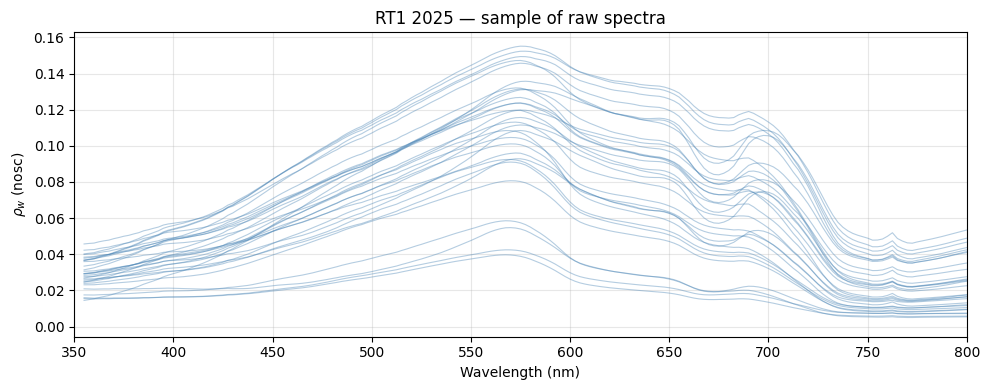

In [4]:
import numpy as np
import matplotlib.pyplot as plt

wl   = datacube['wl']
RHOW = datacube['RHOW']
dateP = datacube['dateP']

print(f"Wavelengths : {wl[0]:.1f} – {wl[-1]:.1f} nm  ({len(wl)} bands)")
print(f"Spectra     : {RHOW.shape[0]}")
print(f"Period      : {min(dateP)}  →  {max(dateP)}")

# plot a random sample of 30 spectra
fig, ax = plt.subplots(figsize=(10, 4))
idx = np.random.choice(RHOW.shape[0], size=min(30, RHOW.shape[0]), replace=False)
for i in idx:
    ax.plot(wl, RHOW[i], alpha=0.4, lw=0.8, color='steelblue')
ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$ (nosc)',
       title=f'{STATION} {YEAR} — sample of raw spectra', xlim=(350, 800))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
